In [6]:
import pandas as pd

products = pd.read_csv("product_info.csv")
reviews = pd.read_csv("reviews_0-250.csv")

print("Products:", products.shape)
print("Reviews:", reviews.shape)

C:\Users\Dodge\AppData\Local\Temp\ipykernel_7568\3778273668.py:4: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.read_csv("reviews_0-250.csv")


Products: (8494, 27)
Reviews: (602130, 19)


In [7]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          8494 non-null   object 
 1   product_name        8494 non-null   object 
 2   brand_id            8494 non-null   int64  
 3   brand_name          8494 non-null   object 
 4   loves_count         8494 non-null   int64  
 5   rating              8216 non-null   float64
 6   reviews             8216 non-null   float64
 7   size                6863 non-null   object 
 8   variation_type      7050 non-null   object 
 9   variation_value     6896 non-null   object 
 10  variation_desc      1250 non-null   object 
 11  ingredients         7549 non-null   object 
 12  price_usd           8494 non-null   float64
 13  value_price_usd     451 non-null    float64
 14  sale_price_usd      270 non-null    float64
 15  limited_edition     8494 non-null   int64  
 16  new   

In [8]:
reviews.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602130 entries, 0 to 602129
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                602130 non-null  int64  
 1   author_id                 602130 non-null  object 
 2   rating                    602130 non-null  int64  
 3   is_recommended            484644 non-null  float64
 4   helpfulness               270298 non-null  float64
 5   total_feedback_count      602130 non-null  int64  
 6   total_neg_feedback_count  602130 non-null  int64  
 7   total_pos_feedback_count  602130 non-null  int64  
 8   submission_time           602130 non-null  object 
 9   review_text               601131 non-null  object 
 10  review_title              435119 non-null  object 
 11  skin_tone                 496074 non-null  object 
 12  eye_color                 463642 non-null  object 
 13  skin_type                 527447 non-null  o

In [9]:
products.isnull().sum()


product_id               0
product_name             0
brand_id                 0
brand_name               0
loves_count              0
rating                 278
reviews                278
size                  1631
variation_type        1444
variation_value       1598
variation_desc        7244
ingredients            945
price_usd                0
value_price_usd       8043
sale_price_usd        8224
limited_edition          0
new                      0
online_only              0
out_of_stock             0
sephora_exclusive        0
highlights            2207
primary_category         0
secondary_category       8
tertiary_category      990
child_count              0
child_max_price       5740
child_min_price       5740
dtype: int64

In [10]:
reviews.isnull().sum()


Unnamed: 0                       0
author_id                        0
rating                           0
is_recommended              117486
helpfulness                 331832
total_feedback_count             0
total_neg_feedback_count         0
total_pos_feedback_count         0
submission_time                  0
review_text                    999
review_title                167011
skin_tone                   106056
eye_color                   138488
skin_type                    74683
hair_color                  141081
product_id                       0
product_name                     0
brand_name                       0
price_usd                        0
dtype: int64

In [11]:
print(type(reviews))
print(type(products))


<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [12]:
df = reviews.merge(
    products,
    on="product_id",
    how="left"
)

print(df.shape)

(602130, 45)


In [13]:
df.columns.tolist()

['Unnamed: 0',
 'author_id',
 'rating_x',
 'is_recommended',
 'helpfulness',
 'total_feedback_count',
 'total_neg_feedback_count',
 'total_pos_feedback_count',
 'submission_time',
 'review_text',
 'review_title',
 'skin_tone',
 'eye_color',
 'skin_type',
 'hair_color',
 'product_id',
 'product_name_x',
 'brand_name_x',
 'price_usd_x',
 'product_name_y',
 'brand_id',
 'brand_name_y',
 'loves_count',
 'rating_y',
 'reviews',
 'size',
 'variation_type',
 'variation_value',
 'variation_desc',
 'ingredients',
 'price_usd_y',
 'value_price_usd',
 'sale_price_usd',
 'limited_edition',
 'new',
 'online_only',
 'out_of_stock',
 'sephora_exclusive',
 'highlights',
 'primary_category',
 'secondary_category',
 'tertiary_category',
 'child_count',
 'child_max_price',
 'child_min_price']

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602130 entries, 0 to 602129
Data columns (total 45 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                602130 non-null  int64  
 1   author_id                 602130 non-null  object 
 2   rating_x                  602130 non-null  int64  
 3   is_recommended            484644 non-null  float64
 4   helpfulness               270298 non-null  float64
 5   total_feedback_count      602130 non-null  int64  
 6   total_neg_feedback_count  602130 non-null  int64  
 7   total_pos_feedback_count  602130 non-null  int64  
 8   submission_time           602130 non-null  object 
 9   review_text               601131 non-null  object 
 10  review_title              435119 non-null  object 
 11  skin_tone                 496074 non-null  object 
 12  eye_color                 463642 non-null  object 
 13  skin_type                 527447 non-null  o

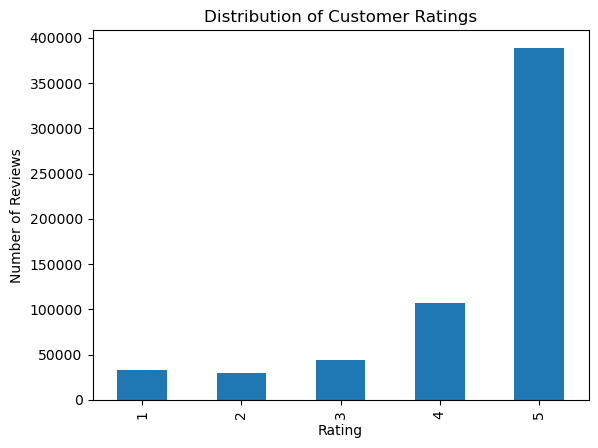

In [15]:
import matplotlib.pyplot as plt

df['rating_x'].value_counts().sort_index().plot(kind='bar')

plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

In [17]:
[col for col in df.columns if 'brand' in col.lower()]

['brand_name_x', 'brand_id', 'brand_name_y']

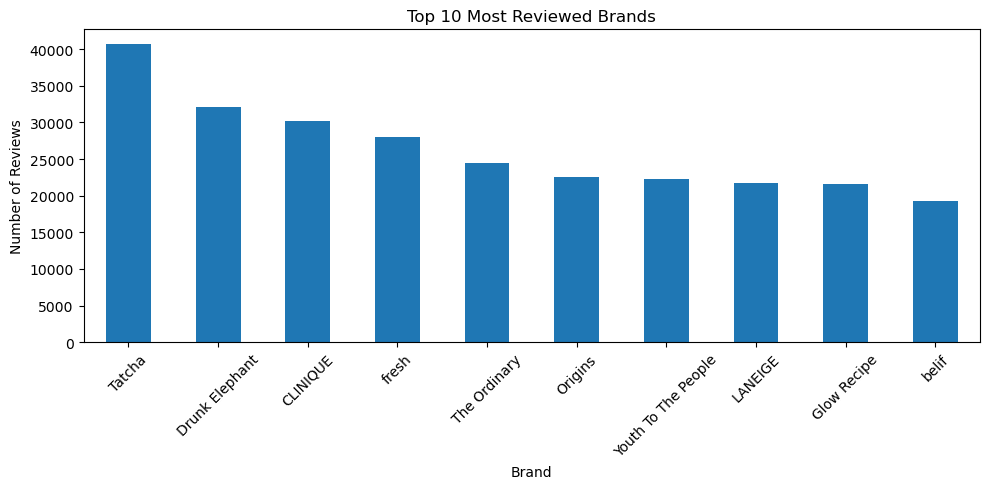

In [18]:
import matplotlib.pyplot as plt

top_brands = df.groupby('brand_name_x')['author_id'].count() \
               .sort_values(ascending=False) \
               .head(10)

top_brands.plot(
    kind='bar',
    figsize=(10,5),
    title='Top 10 Most Reviewed Brands'
)

plt.ylabel('Number of Reviews')
plt.xlabel('Brand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
[col for col in df.columns if 'rating' in col.lower()]

['rating_x', 'rating_y']

In [20]:
brand_stats = df.groupby('brand_name_x').agg({
    'rating_x': ['mean', 'count']
})

brand_stats.columns = ['avg_rating', 'review_count']

brand_stats = brand_stats[
    brand_stats['review_count'] >= 100
]

top_rated = brand_stats.sort_values(
    'avg_rating',
    ascending=False
).head(10)

print(top_rated)

                           avg_rating  review_count
brand_name_x                                       
Jack Black                   4.681780          3595
Dermalogica                  4.663636         11660
Bobbi Brown                  4.605929          3441
Shiseido                     4.587074         11249
Dr. Brandt Skincare          4.578770          1187
innisfree                    4.572447          2664
Evian                        4.563226          1550
Rosebud Perfume Co.          4.554446         12021
Dr. Dennis Gross Skincare    4.526336         10290
belif                        4.490944         19324


In [21]:
[col for col in df.columns if 'price' in col.lower()]

['price_usd_x',
 'price_usd_y',
 'value_price_usd',
 'sale_price_usd',
 'child_max_price',
 'child_min_price']

In [22]:
df['price_usd_x'].describe()

count    602130.000000
mean         45.723937
std          35.743990
min           3.000000
25%          23.500000
50%          38.000000
75%          60.000000
max         380.000000
Name: price_usd_x, dtype: float64

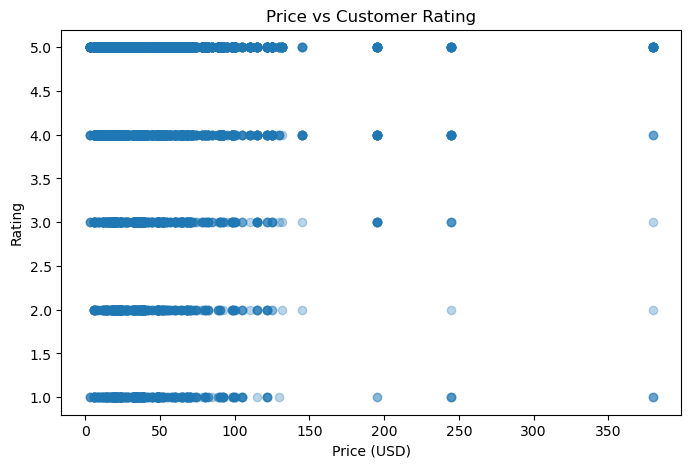

In [23]:
import matplotlib.pyplot as plt

sample = df.sample(10000, random_state=42)

plt.figure(figsize=(8,5))

plt.scatter(
    sample['price_usd_x'],
    sample['rating_x'],
    alpha=0.3
)

plt.xlabel('Price (USD)')
plt.ylabel('Rating')
plt.title('Price vs Customer Rating')
plt.show()

In [24]:
df[['price_usd_x', 'rating_x']].corr()

,price_usd_x,rating_x
price_usd_x,1.000000,-0.010423
rating_x,-0.010423,1.000000


In [25]:
df.groupby('skin_type')['rating_x'].agg(['mean','count'])

,mean,count
skin_type,,
combination,4.314234,292308
dry,4.287193,99574
normal,4.294938,69435
oily,4.287978,66130


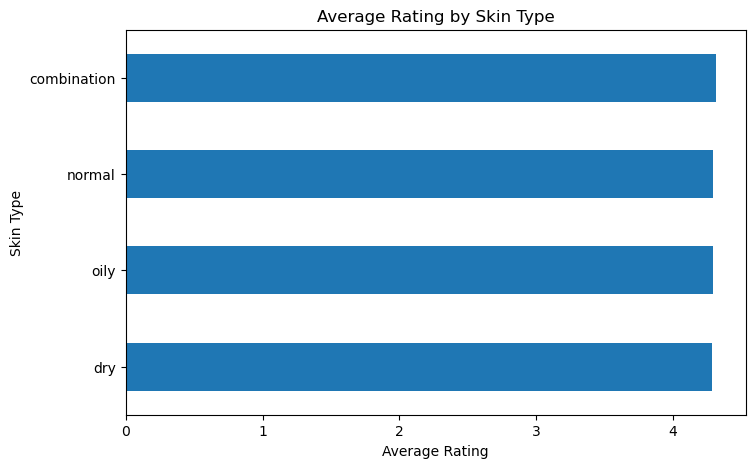

In [26]:


skin_ratings = df.groupby('skin_type')['rating_x'].mean()

skin_ratings.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Average Rating by Skin Type')
plt.xlabel('Average Rating')
plt.ylabel('Skin Type')
plt.show()

In [27]:
positive_reviews = df[df['rating_x'] >= 4]
negative_reviews = df[df['rating_x'] <= 2]

print("Positive reviews:", len(positive_reviews))
print("Negative reviews:", len(negative_reviews))

Positive reviews: 495956
Negative reviews: 62156


In [28]:
positive_pct = (495956 / len(df)) * 100
negative_pct = (62156 / len(df)) * 100

print(f"Positive: {positive_pct:.1f}%")
print(f"Negative: {negative_pct:.1f}%")

Positive: 82.4%
Negative: 10.3%


In [29]:
df.to_csv("sephora_cleaned.csv", index=False)